In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

**Exercise 5.1.2**

The following table gives us the life expectancy in the U.S. by year of birth.

|1980|1985|1990|1995|2000|2005|2010|
|----|----|----|----|----|----|----|
|73.7|74.7|75.4|75.8|77.0|77.8|78.7|

(a) Defining "year since 1980" as the independent variable, follow the method of Example 5.1.1 to construct and plot the polynomial interpolant of the data.

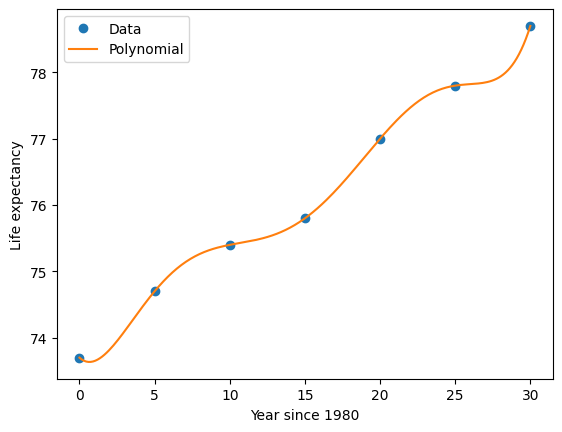

In [3]:
x = [0, 5, 10, 15, 20, 25, 30]
y = [73.7, 74.7, 75.4, 75.8, 77.0, 77.8, 78.7]

polynomial_interp = np.poly1d(np.polyfit(x, y, len(x) - 1))
x_space = np.linspace(0, 30, 200)

plt.xlabel("Year since 1980")
plt.ylabel("Life expectancy")
plt.plot(x, y, "o", label = "Data")
plt.plot(x_space, polynomial_interp(x_space), label = "Polynomial")
plt.legend()
plt.show()

(b) Follow the method of Example 5.1.3 to construct and plot a piecewise cubic interpolant of the data.

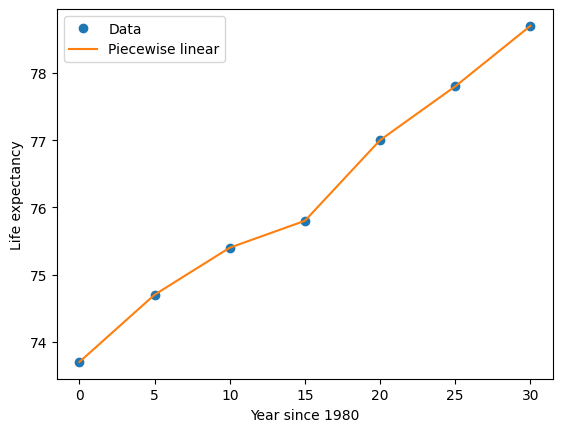

In [4]:
p_linear_interp = interp1d(x, y, kind = "linear")

plt.xlabel("Year since 1980")
plt.ylabel("Life expectancy")
plt.plot(x, y, "o",label = "Data")
plt.plot(x_space, p_linear_interp(x_space), label = "Piecewise linear")
plt.legend()
plt.show()

(c) Use both methods to estimate the life expectancy for a person born in 2007. Which value is more believable?

In [5]:
print(f"The polynomial estimates {polynomial_interp(2007 - 1980)}")
print(f"The piecewise linear estimates {p_linear_interp(2007 - 1980)}")

The polynomial estimates 77.8474995199997
The piecewise linear estimates 78.16


The piecewise linear estimate seems more believable. The polynomial estimate is almost exactly the same as the data point for 2005, even though 2007 is two years after.

**Exercise 5.2.1**

For each given function and interval, perform piecewise linear interpolation using Function 5.2.2 for $n+1$ equispaced nodes with $n=10,20,40,80,160,320,640$. For each $n$, estimate the error

$$E(n)=\lVert f-p\rVert_\infty=\max_x|f(x)-p(x)|$$

by evaluating the function and interpolant at 1600 points in the interval. Make a log-log plot of $E$ as a function of $n$ and add the line $E=Cn^{-2}$ for a constant $C$ of your choosing.

In [6]:
def hatfun(t, k):
    """
    hatfun(t, k)

    Returns a piecewise linear "hat" function,  where t is a vector of
    n+1 interpolation nodes and k is an integer in 0:n giving the index of the node
    where the hat function equals one.
    """
    n = len(t) - 1

    def evaluate(x):
        H = np.zeros(np.array(x).shape)
        for (j, xj) in enumerate(x):
            if (k > 0) and (t[k-1] <= xj) and (xj <= t[k]):
                H[j] = (xj - t[k-1]) / (t[k] - t[k-1])
            elif (k < n) and (t[k] <= xj) and (xj <= t[k+1]):
                H[j] = (t[k+1] - xj) / (t[k+1] - t[k])
        return H
    return evaluate

def plinterp(t, y):
    """
    plinterp(t, y)

    Create a piecewise linear interpolating function for data values in y given at nodes
    in t.
    """
    n = len(t) - 1
    H = [hatfun(t, k) for k in range(n+1)]
    def evaluate(x):
        f = 0
        for k in range(n+1):
            f += y[k] * H[k](x)
        return f
    return evaluate



In [7]:
n_values = [10, 20, 40, 80, 160, 320, 360]
n_space = np.linspace(10, 360, 200)

def do_the_thing(f, min, max, c, interp_f = plinterp, n_power = -2):
    evaluation_space = np.linspace(min, max, 1600)
    errors = []

    for n in n_values:
        x_space = np.linspace(min, max, n + 1)
        p = interp_f(x_space, f(x_space))
        error = np.max(np.abs(f(evaluation_space) - p(evaluation_space)))
        errors.append(error)
    
    e = lambda n: c * (n ** n_power)

    plt.xlabel("n")
    plt.ylabel("Error")
    plt.loglog(n_values, errors, "-o", label = "Errors")
    plt.loglog(n_space, e(n_space), label = f"E = {c} * n^{n_power}")
    plt.legend()
    plt.show()

(a) $\cos(\pi x^2)$ on $[0,4]$

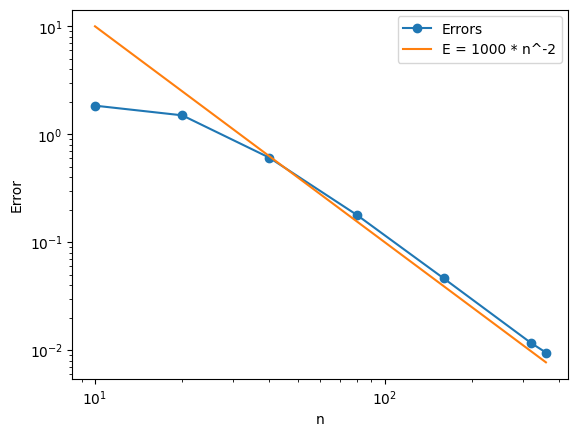

In [8]:
do_the_thing(lambda x: np.cos(np.pi * x ** 2), 0, 4, 10 ** 3)

(b) $\ln(x)$ on $[1,20]$

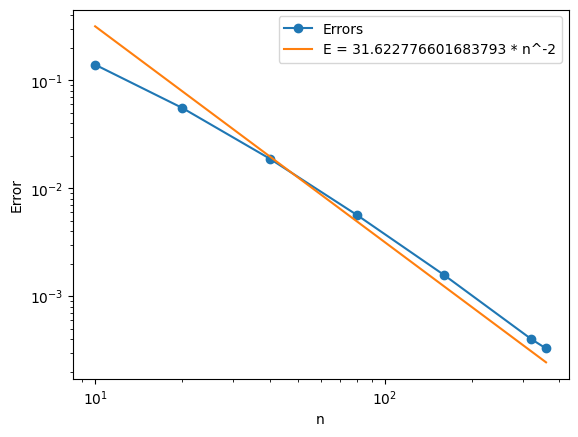

In [9]:
do_the_thing(lambda x: np.log(x), 1, 20, 10 ** 1.5)

(c) $\sin(1/x)$ on $[1/2,7]$

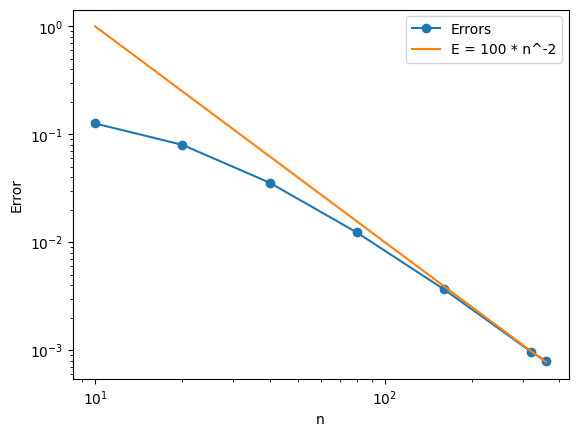

In [10]:
do_the_thing(lambda x: np.sin(1 / x), 0.5, 7, 10 ** 2)

**Exercise 5.2.3**

Before electronic calculators, the function $ln(x)$ was often computed using piecewise linear interpolation with a table of values. If you were using such a table at the nodes $3.0,3.1,3.2,\dots,3.9,4.0$, what is an upper bound on the error in the result over the interval $[3,4]$?

On some $[t,t+0.1]$, the piecewise interpolant would be $p(x)=\ln(t)+10(\ln(t+0.1)-\ln(t))(x-t)$, the error would be $e(x)=ln(x)-p(x)$, and the derivative of that would be $e'(x)=1/x-10(\ln(t+0.1)-\ln(t))$. When this equals $0$, we have $e_\text{max}=1/(10(\ln(t+0.1) - \ln(t)))$, the value at which the absolute maximum of our error occurs that interval.

We find that $\max_t(|\ln(e_\text{max,t})-p_t(e_\text{max,t})|)$ for $t\in[3.0,3.1,\dots,3.9]$ is $0.697$, achieved on the $[3.9,4.0]$ piecewise interpolant.

**Exercise 5.2.4**

Show that for any node distribution and any $x\in[t_0,t_n]$,

$$\sum_{k=0}^{n} H_k(x)=1$$

(Hint: The simplest way is to apply (5.2.5).) This is called the *partition of unity* property.

For any $x\in[t_0,t_n]$, $H_i(x)=0$ if $x\not\in[t_{i-1},t_{i+1}]$, so for $x\in[t_i,t_{i+1}]$ for any $i\in[0..n]$, $\sum H_k(x)=H_i(x)+H_{i+1}(x)$. Furthermore,

$$H_i(x)+H_{i+1}=\frac{t_{i+1}-x}{t_{i+1}-t_i}+\frac{x-t_{k-1+1}}{t_{k+1-1}-t_{k-1+1}}=\frac{t_{k+1}-x+x-t_k}{t_{k+1}-t_k}=1$$

So $\sum H_k(x)=1$.

Honestly I don't really understand what the (5.2.5) method would be; this is best understood when looking at Example 5.2.1 in my opinion.

**Exercise 5.3.3**

For each given function, interval, and value of $n$, define $n+1$ evenly spaced nodes. Then use Function 5.3.1 to plot the cubic spline interpolant using those nodes, together with the data at the nodes and the original function over the given interval.

In [11]:
def spinterp(t, y):
    """
    spinterp(t, y)

    Create a cubic not-a-knot spline interpolating function for data values in y given at nodes in t.
    """
    n = len(t) - 1
    h = [t[i + 1] - t[i] for i in range(n)]

    # Preliminary definitions.
    Z = np.zeros([n, n])
    I = np.eye(n)
    E = I[: n - 1, :]
    J = np.eye(n) + np.diag(-np.ones(n - 1), 1)
    H = np.diag(h)

    # Left endpoint interpolation:
    AL = np.hstack([I, Z, Z, Z])
    vL = y[:-1]

    # Right endpoint interpolation:
    AR = np.hstack([I, H, H**2, H**3])
    vR = y[1:]

    # Continuity of first derivative:
    A1 = E @ np.hstack([Z, J, 2 * H, 3 * H**2])
    v1 = np.zeros(n - 1)

    # Continuity of second derivative:
    A2 = E @ np.hstack([Z, Z, J, 3 * H])
    v2 = np.zeros(n - 1)

    # Not-a-knot conditions:
    nakL = np.hstack([np.zeros(3 * n), np.hstack([1, -1, np.zeros(n - 2)])])
    nakR = np.hstack([np.zeros(3 * n), np.hstack([np.zeros(n - 2), 1, -1])])

    # Assemble and solve the full system.
    A = np.vstack([AL, AR, A1, A2, nakL, nakR])
    v = np.hstack([vL, vR, v1, v2, 0, 0])
    z = np.linalg.solve(A, v)

    # Break the coefficients into separate vectors.
    rows = np.arange(n)
    a = z[rows]
    b = z[n + rows]
    c = z[2 * n + rows]
    d = z[3 * n + rows]
    S = [np.poly1d([d[k], c[k], b[k], a[k]]) for k in range(n)]

    # This function evaluates the spline when called with a value for x.
    def evaluate(x):
        f = np.zeros(x.shape)
        for k in range(n):
            # Evaluate this piece's cubic at the points inside it.
            index = (x >= t[k]) & (x <= t[k + 1])
            f[index] = S[k](x[index] - t[k])
        return f

    return evaluate

In [12]:
def do_the_other_thing(f, min, max, n):
    nodes = np.linspace(min, max, n + 1)
    node_space = np.linspace(min, max, 200)
    interpolant = spinterp(nodes, f(nodes))

    plt.xlabel("x")
    plt.ylabel("y")
    plt.plot(nodes, f(nodes), "o", label = "Data")
    plt.plot(node_space, interpolant(node_space), label = "Interpolant")
    plt.legend()
    plt.show()

(a) $\cos(\pi x^2)$ on $[0,4]$, $n=18$

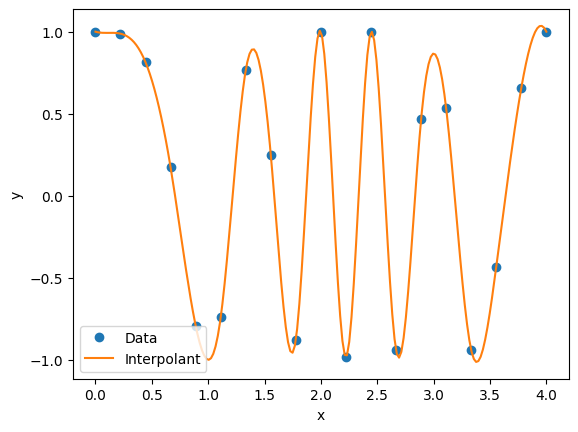

In [13]:
do_the_other_thing(lambda x: np.cos(np.pi * x ** 2), 0, 4, 18)

(b) $\ln(x)$ on $[1,20]$, $n=4$

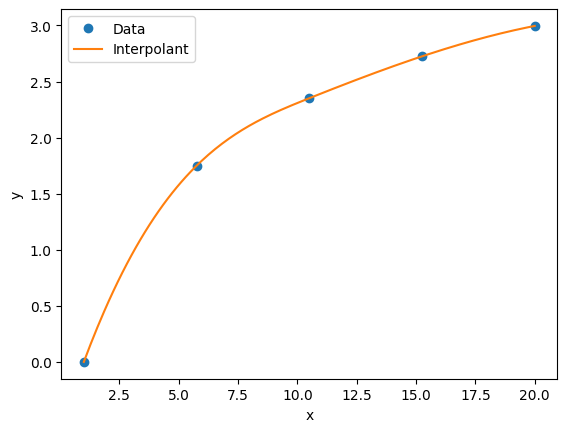

In [14]:
do_the_other_thing(lambda x: np.log(x), 1, 20, 4)

(c) $\sin(1/x)$ on $[1/2,7]$, $n=9$

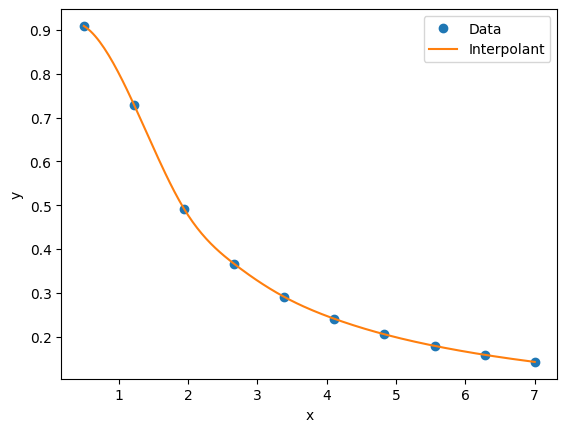

In [15]:
do_the_other_thing(lambda x: np.sin(1 / x), 0.5, 7, 9)

**Exercise 5.3.4**

For each given function and interval, perform cubic spline interpolation using Function 5.3.1 for $n+1$ equispaced nodes with $n=10,20,40,80,160,320,640$. For each $n$, estimate the error

$$E(n)=\lVert f-p\rVert_\infty=\max_x|f(x)-p(x)|$$

by evaluating the function and interpolant at 1600 points in the interval. Make a log-log plot of $E$ as a function of $n$ and add the line $E=Cn^{-4}$ for a constant $C$ of your choosing.

(a) $\cos(\pi x^2)$ on $[0,4]$

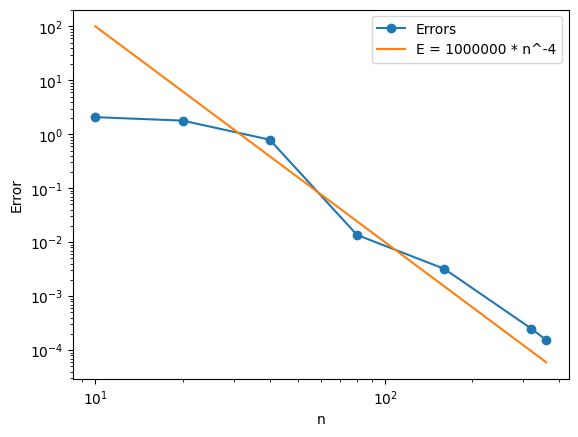

In [16]:
do_the_thing(lambda x: np.cos(np.pi * x ** 2), 0, 4, 10 ** 6, spinterp, -4)

(b) $\ln(x)$ on $[1,20]$

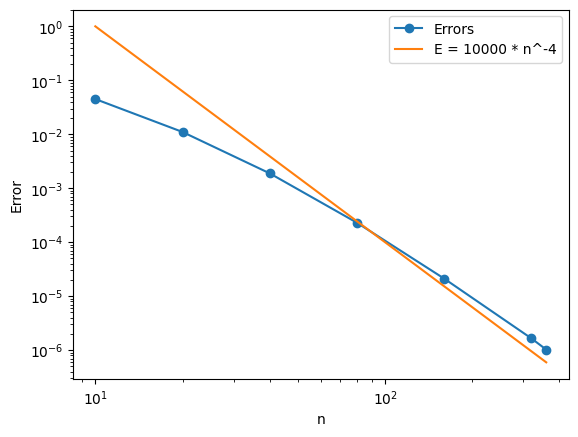

In [17]:
do_the_thing(lambda x: np.log(x), 1, 20, 10 ** 4, spinterp, -4)

(c) $\sin(1/x)$ on $[1/2,7]$

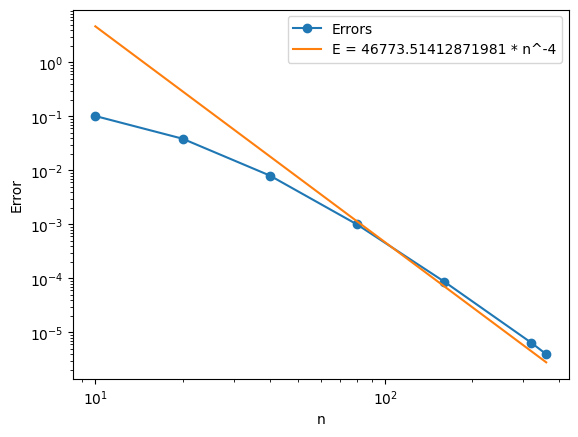

In [18]:
do_the_thing(lambda x: np.sin(1 / x), 0.5, 7, 10 ** 4.67, spinterp, -4)

**Exercise 5.4.2**

(a) Table 5.4.2 lists forward difference formulas in which $p=0$ in (5.4.1). Show that the change of variable $g(x)=f(-x)$ transforms these formulas into backward difference formulas with $q=0$, and write out the table analogous to Table 5.4.2 for backward differences.

Since $g(x)=f(-x)$, $g'(x)=-f(-x)$ by chain rule.

We start with our finite-difference formula.

$$f'(x)\approx\frac{1}{h}\sum_{k=-p}^{q}a_kf(x+kh)$$

We apply $g'(x)=-f(-x)$ to it.

$$\begin{align*}
g'(x)&\approx\frac{1}{h}\sum_{k=-p}^{q}a_kg(x+kh)\\
-f'(-x)&=\frac{1}{h}\sum_{k=-p}^qa_kf(-x-kh)\\
\to f'(-x)&=\frac{1}{h}\sum_{k=-p}^q(-a_k)f(-x-kh)
\end{align*}$$

We're able to change the bounds of this summation so it follows the backward difference formula definition.

$$\begin{align*}
f'(-x)&=\frac{1}{h}\sum_{k=-p}^q(-a_k)f(-x-kh)\\
&=\frac{1}{h}((-a_0)f(-x)+(-a_1)f(-x-h)+\cdots+(-a_q)f(-x-qh))\\
&=\frac{1}{h}((-a_q)f(-x-qh)+(-a_{q-1})f(-x-(q-1)h)+\cdots+(-a_0)f(-x))\\
&=\frac{1}{h}\sum_{i=-q}^p(-a_{-i})f(-x+ih)
\end{align*}$$

This is a finite-difference formula starting at some $i<0$ and ending at $i=0$, satisfying the backwards difference formula definition.

|order|$0$|$-h$|$-2h$|$-3h$|$-4h$|
|-----|---|----|-----|-----|-----|
|1    |1  |-1  |     |     |     |
|2    |3/2|-2  |1/2  |     |     |
|3    |11/6|-3 |3/2  |-1/3 |     |
|4    |25/12|-4|3    |-4/3 |1/4  |

(b) Suppose you are given the nodes $t_0=0.9$, $t_1=1$, and $t_2=1.1$, and $f(x)=\sin(2x)$. Using formulas from Table 5.4.1 and Table 5.4.2, compute second-order accurate approximations to $f'$ at each of the three nodes.

In [26]:
f = lambda x: np.sin(2 * x)

h = np.finfo(float).eps ** (2/3)

weights = {
    -2: 1/2,
    -1: -2,
    0: 3/2
}

def f_prime_approx(x):
    f_prime = 0
    for k in range(-2, 0 + 1):
        f_prime += weights[k] * f(x + k * h)
    return f_prime / h

print(f"f'(0.9) ~ {f_prime_approx(0.9)}")
print(f"f'(1.0) ~ {f_prime_approx(1.0)}")
print(f"f'(1.1) ~ {f_prime_approx(1.1)}")

f'(0.9) ~ -0.4544013021075956
f'(1.0) ~ -0.8322979926636538
f'(1.1) ~ -1.1769926264572395


**Exercise 5.4.5**

For this problem, let $f(x)=\tan(2x)$.

In [27]:
def fdweights(t, m):
    """
    fdweights(t, m)

    Return weights for the mth derivative of a function at zero using values at the
    nodes in vector t.
    """
    # This is a compact implementation, not an efficient one.

    def weight(t, m, r, k):
        # Recursion for one weight.
        # Input:
        #   t   nodes (vector)
        #   m   order of derivative sought
        #   r   number of nodes to use from t (<= length(t))
        #   k   index of node whose weight is found

        if (m < 0) or (m > r):  # undefined coeffs must be zero
            c = 0
        elif (m == 0) and (r == 0):  # base case of one-point interpolation
            c = 1
        else:  # generic recursion
            if k < r:
                denom = t[r] - t[k]
                c = (t[r] * weight(t, m, r-1, k) - m * weight(t, m-1, r-1, k)) / denom
            else:
                beta = np.prod(t[r-1] - t[:r-1]) / np.prod(t[r] - t[:r])
                c = beta * (m * weight(t, m-1, r-1, r-1) - t[r-1] * weight(t, m, r-1, r-1))
        return c

    r = len(t) - 1
    w = np.zeros(t.shape)
    return np.array([ weight(t, m, r, k) for k in range(r+1) ])

(a) Apply Function 5.4.1 to find a finite-difference approximation to $f''(0.3)$ using the five nodes $t_j=0.3+jh$ for $j=-2,\dots,2$ and $h=0.05$. Compare to the exact value of $f''(0.3)$.

In [31]:
h = 0.05
t = np.array([0.2, 0.25, 0.3, 0.35, 0.4])

f = lambda x: np.tan(2 * x)
f_double_prime = lambda x: 8 * np.tan(2 * x) / (np.cos(2 * x) ** 2)

w = fdweights(t - 0.3, 2)
print(f"f''(0.3) = {f_double_prime(0.3)} ~ {np.dot(w, f(t))}")

f''(0.3) = 8.034738964488714 ~ 8.030596629020792


(b) Repeat part (a) for $f''(0.75)$ on the nodes $t_j=0.75+jh$. Why is the finite-difference result so inaccurate? (Hint: A plot of $f$ might be informative.)

In [32]:
t = np.array([0.65, 0.7, 0.75, 0.8, 0.85])

w = fdweights(t - 0.75, 2)
print(f"f''(0.75) = {f_double_prime(0.75)} ~ {np.dot(w, f(t))}")

f''(0.75) = 22545.355234632298 ~ -29130.08276816167


The finite-difference result is so inaccurate because $t$ spans a break in the continuity of $f$.

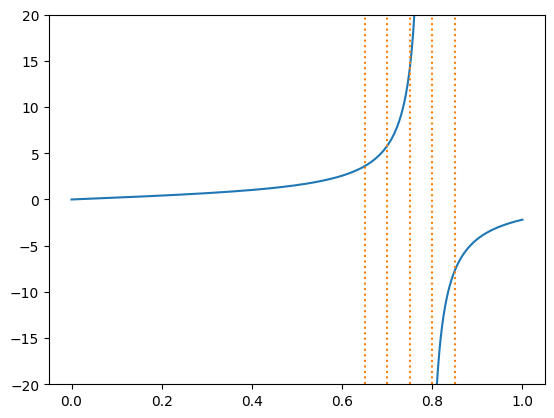

In [49]:
x_1 = np.linspace(0, np.pi / 4, 200)
x_2 = np.linspace(np.pi / 4 + 0.001, 1, 200)

plt.plot(x_1, f(x_1), color = "C0")
plt.plot(x_2, f(x_2), color = "C0")
plt.vlines(t, -20, 20, colors = "C1", linestyles="dotted")
plt.ylim(-20, 20)
plt.show()

**Exercise 5.5.2**

Derive the first two nonzero terms of the Taylor series at $h=0$ of the truncation error $\tau_f(h)$ for the formula (5.4.3).

$$\begin{align*}
\tau_f(h)&=f'(0)-\frac{f(0)-f(-h)}{h}\\
&=f'(0)-h^{-1}\left(f(0)-\left(f(0)-f'(0)h+\frac{f''(0)}{2}h^2-\frac{f'''(0)}{6}h^3+\cdots\right)\right)\\
&=f'(0)-h^{-1}\left(f'(0)h-\frac{f''(0)}{2}h^2+\frac{f'''(0)}{6}h^3-\cdots\right)\\
&=\frac{f''(0)}{2}h-\frac{f'''(0)}{6}h^2+\cdots
\end{align*}$$

**Exercise 5.5.5**

Show that the formula (5.4.9) is second-order accurate.

To show $f''(0)\approx\frac{1}{h^2}(f(-h)-2f(0)+f(h))$ is second-order accurate, we must show the truncation error is $O(h^2)$.

$$\tau_f(h)=f''(0)-\frac{f(-h)-2f(0)+f(h)}{h^2}$$

We Taylor expand $f(-h)$ and $f(h)$.

$$\begin{align*}
f(-h)&=f(0)-f'(0)h+\frac{f''(0)}{2}h^2-\frac{f'''(0)}{6}h^3+\frac{f''''(0)}{12}h^4-\cdots\\
f(h)&=f(0)+f'(0)h+\frac{f''(0)}{2}h^2+\frac{f'''(0)}{6}h^3+\frac{f''''(0)}{12}h^4+\cdots\\
\end{align*}$$

When calculating the sum $f(-h)-2f(0)+f(h)$, we find that every other term cancels.

$$f(-h)-2f(0)+f(h)=(-2f(0)+2f(0))+f''(0)h^2+\frac{f''''(0)}{6}h^4+\cdots$$

Putting this back into the first equation,

$$\begin{align*}
\tau_f(h)&=f''(0)-h^{-2}(f''(0)h^2+\frac{f''''(0)}{6}h^4+\cdots)\\
&=(f''(0)-f''(0))+\frac{f''''(0)}{6}h^2+\cdots\\
&=\frac{f''''(0)}{6}h^2+\cdots=O(h^2)
\end{align*}$$

so this formula is second-order accurate.

**Exercise 5.6.5**

Show that the Simpson formula (5.6.21) is equivalent to $S_f(n)$, given the definition of $S_f$ in (5.6.14).

We must show that

$$\frac{h}{3}(f(t_0)+4f(t_1)+2f(t_2)+4f(t_3)+2f(t_4)+\cdots+2f(t_{n-2})+4f(t_{n-1})+f(t_n))=\frac{1}{3}(4T_f(2n)-T_f(n))$$

In the context of $2n$ nodes, $T_f(n)=2h(\frac{1}{2}f(t_0)+f(t_1)+\cdots+f(t_{n-1})+\frac{1}{2}f(t_n)))$, and $T_f(2n)=h(\frac{1}{2}f(t_0)+f(t_1)+\cdots+f(t_{n-1})+\frac{1}{2}f(t_n)))$. Thus,

$$\begin{align*}
\frac{1}{3}(4T_f(2n)-T_f(n))&=\frac{h}{3}((2f(t_0)-f(t_0))+(4f(t_1))+(4f(t_2)-2f(t_2))+(4f(t_3))+(4f(t_4)-2f(t_2))+\cdots+(4f(t_{n-1}))+(2f(t_n)-f(t_n)))\\
&=\frac{h}{3}(f(t_0)+4f(t_1)+2f(t_2)+4f(t_3)+2f(t_4)+\cdots+4f(t_{n-1})+f(t_n))
\end{align*}$$

which is exactly equivalent.